In [9]:
# !pip install statsmodels 
# !pip install --upgrade statsmodels

In [10]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import re
import inspect
from datetime import datetime
from statsmodels.tsa.arima.model import ARIMA

In [11]:

DB_FILE = "social_media_analytics.db"
table_name = "social_media_posts"
db_path = os.path.abspath("social_media_analytics.db")
connection = sqlite3.connect(DB_FILE)

q5 = pd.read_sql(f"""
    SELECT
        SUBSTR(post_date,1,7) AS month,
        COUNT (*) AS total_posts,
        ROUND(AVG(engagement_rate),2) AS avg_engagement,
        SUM(likes) AS total_likes,
        SUM(shares) AS total_shares
    FROM {table_name}
    WHERE post_date IS NOT NULL
    GROUP BY SUBSTR(post_date,1,7)
    ORDER BY month ASC
    LIMIT 10
""",connection)

connection.close()
q5_ts = q5.copy()

In [12]:
q5_ts["month"] = pd.to_datetime(q5_ts["month"], format ="%Y-%m")
q5_ts = q5_ts.set_index("month").asfreq("MS")  # MS = month start frquency


# Fill any missing months with interpolation 
q5_ts["total_posts"] = q5_ts["total_posts"].interpolate()
q5_ts["avg_engagement"] = q5_ts["avg_engagement"].interpolate()

print(f"Time series prepared: {len(q5_ts)} months")
print(f" Date range: {q5_ts.index.min()} -> {q5_ts.index.max()}")
q5_ts[["total_posts","avg_engagement"]]
q5_ts.head()

Time series prepared: 10 months
 Date range: 2024-01-01 00:00:00 -> 2024-10-01 00:00:00


,total_posts,avg_engagement,total_likes,total_shares
month,,,,
2024-01-01,184,14.79,1373447,129006
2024-02-01,190,12.68,1704248,166527
2024-03-01,218,12.44,1935586,203341
2024-04-01,236,8.63,1828457,196183
2024-05-01,227,5.85,1450671,182940


In [13]:
# Step 3 - Check if data is stationary 

from statsmodels.tsa.stattools import adfuller

def check_stationary(series, name):
    result = adfuller(series.dropna())
    print(f"\n {name}")
    print(f" ADF Statistic: {result[0]:.4f}")
    print(f" p-value: {result[1]:.4f}")
    if result[1] <= 0.05:
        print(f" Stationary (p <= 0.05) - good for ARIMA")
    else:
        print(f" Non-stationary (p > 0.05) - will need differencing")

check_stationary(q5_ts["total_posts"], "Total Posts")
check_stationary(q5_ts["avg_engagement"], "Avg Engagement")



 Total Posts
 ADF Statistic: -1.4667
 p-value: 0.5499
 Non-stationary (p > 0.05) - will need differencing

 Avg Engagement
 ADF Statistic: -1.6988
 p-value: 0.4318
 Non-stationary (p > 0.05) - will need differencing


In [14]:
# Step 4 - Fits ARIMA models

# Fit ARIMA for total_posts
# order = (p,d,q) : p = autoregressive terms, d = differencing, q = moving average terms

# p = range(0,3)
# q = range(0,2)
# d = range(0,3)
# pdq_combinations = list(itertools.product(p,d,q))
# best_aic = float("inf")
# best_order = None
# for order in pdq_combinations:
#     try:
#         model = ARIMA(tra)


model_posts = ARIMA(q5_ts["total_posts"], order = (1,0,0))
fit_posts = model_posts.fit()

# Fit ARIMA for average engagement
model_engagement = ARIMA(q5_ts["avg_engagement"], order = (1,0,0))
fit_engagement = model_engagement.fit()

print(f" Both models fitted")
print(f" Total posts model AIC: {fit_posts.aic:.2f}")
print(f" Average engagement model AIC: {fit_engagement.aic:.2f}")





 Both models fitted
 Total posts model AIC: 88.70
 Average engagement model AIC: 54.29


In [15]:
# Forecast in the next 6 months 
FORECAST_MONTHS = 6

forecast_posts = fit_posts.get_forecast(steps = FORECAST_MONTHS)
forecast_engagement = fit_engagement.get_forecast(steps = FORECAST_MONTHS)

# Build forecast dataframe with confidence intervals
future_dates = pd.date_range(
    start = q5_ts.index[-1] + pd.DateOffset(months=1),
    periods = FORECAST_MONTHS, freq = "MS"
)

forecast_df = pd.DataFrame({
    "month": future_dates,
    "forecast_posts": forecast_posts.predicted_mean.values,
    "posts_lower_ci": forecast_posts.conf_int().iloc[:,0].values,
    "posts_upper_ci": forecast_posts.conf_int().iloc[:,1].values,
    "forecast_engagement": forecast_engagement.predicted_mean.values,
    "engagement_lower_ci": forecast_engagement.conf_int().iloc[:,0].values,
    "engagement_upper_ci": forecast_engagement.conf_int().iloc[:,1].values,
}).set_index("month")

print("6 - month forecast generated")
forecast_df.round(2)

6 - month forecast generated


,forecast_posts,posts_lower_ci,posts_upper_ci,forecast_engagement,engagement_lower_ci,engagement_upper_ci
month,,,,,,
2024-11-01,202.00,172.80,231.20,13.14,7.92,18.37
2024-12-01,201.49,168.78,234.20,12.30,6.44,18.17
2025-01-01,201.24,167.69,234.78,11.88,5.86,17.89
2025-02-01,201.11,167.36,234.86,11.66,5.61,17.72
2025-03-01,201.04,167.24,234.85,11.55,5.49,17.62
2025-04-01,201.01,167.19,234.83,11.50,5.43,17.56


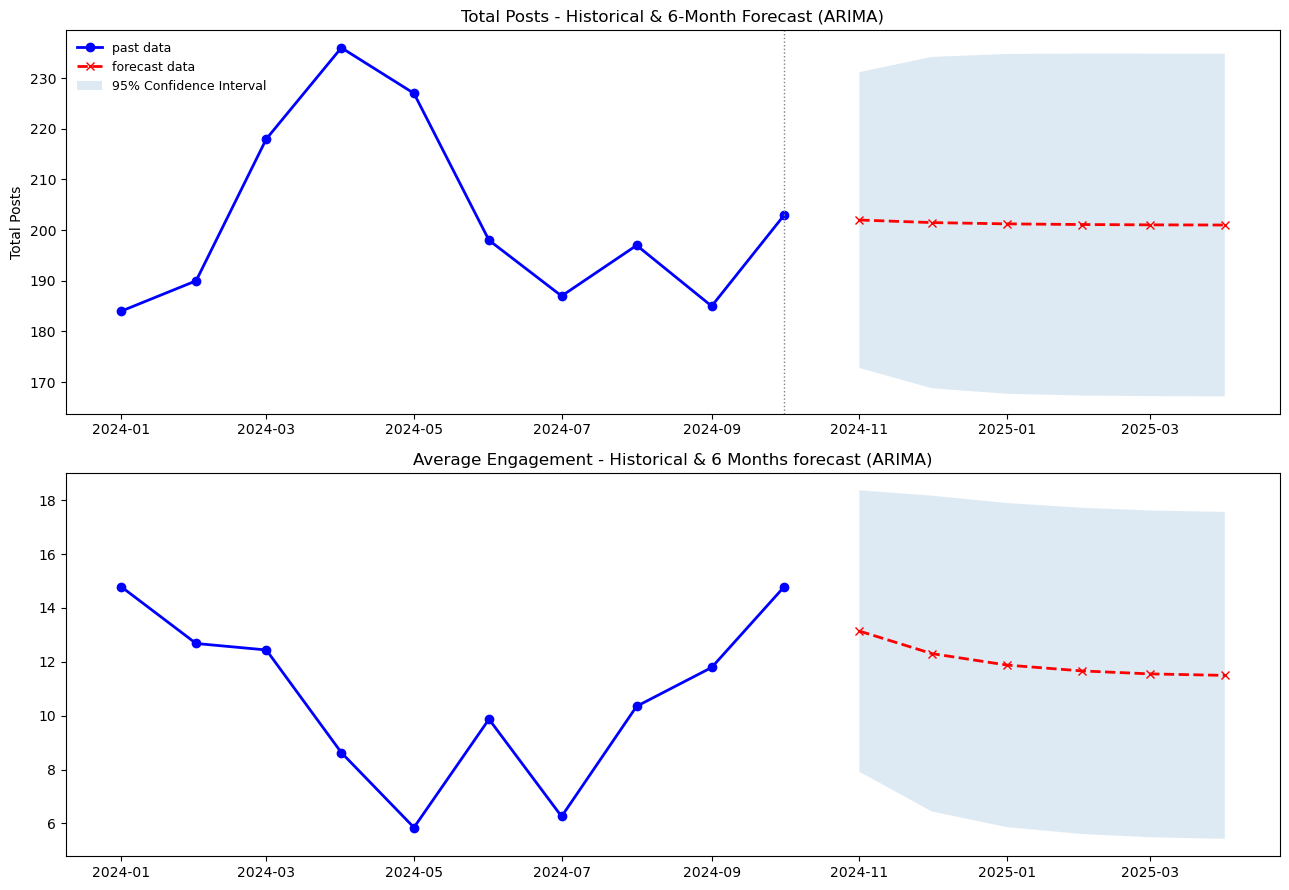

In [16]:
# Step 6 - Visulize historical and forecast

# total posts forecast
fig, axes = plt.subplots(2,1,figsize = (13, 9))
axes[0].plot(q5_ts.index, q5_ts["total_posts"],
            label = "past data", color = "blue", linewidth = 2, marker = "o")
axes[0].plot(forecast_df.index, forecast_df["forecast_posts"],
           label = "forecast data", color = "red", linewidth = 2, linestyle = "--", marker = "x")
axes[0].fill_between(forecast_df.index,
                    forecast_df["posts_lower_ci"], forecast_df["posts_upper_ci"],
                    alpha = 0.15, label ="95% Confidence Interval")

axes[0].axvline(q5_ts.index[-1], color = "gray", linestyle = ":", linewidth = 1)
axes[0].set_title("Total Posts - Historical & 6-Month Forecast (ARIMA)" )
axes[0].set_ylabel("Total Posts")
axes[0].legend(frameon = False, fontsize = 9)

# Engagement Rate forecast
axes[1].plot(q5_ts.index, q5_ts["avg_engagement"],
            label = "Past data", color = "blue", linewidth = 2, marker = "o")
axes[1].plot(forecast_df.index,forecast_df["forecast_engagement"],
            label ="Forecast", color = "red", linewidth = 2, 
             linestyle ="--", marker = "x")
axes[1].fill_between(forecast_df.index, 
                    forecast_df["engagement_lower_ci"], forecast_df["engagement_upper_ci"],
                    alpha = 0.15, label = "95% Confidence Interval")
axes[1].set_title("Average Engagement - Historical & 6 Months forecast (ARIMA)")


plt.tight_layout()
plt.show()


